# ML Modeling to Predict Soil Organic Carbon from the Processed Data

## Introduction

This is work on the modelling  for prediction of Soil Organic Carbon of Sichei Area in Western Kenya. This will be done in the following ways:

In [305]:
# 🔄 Automatically reload imports if the source code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Processing
## Loading Data

Text(83.95398132132443, 0.5, 'Northings (m)')

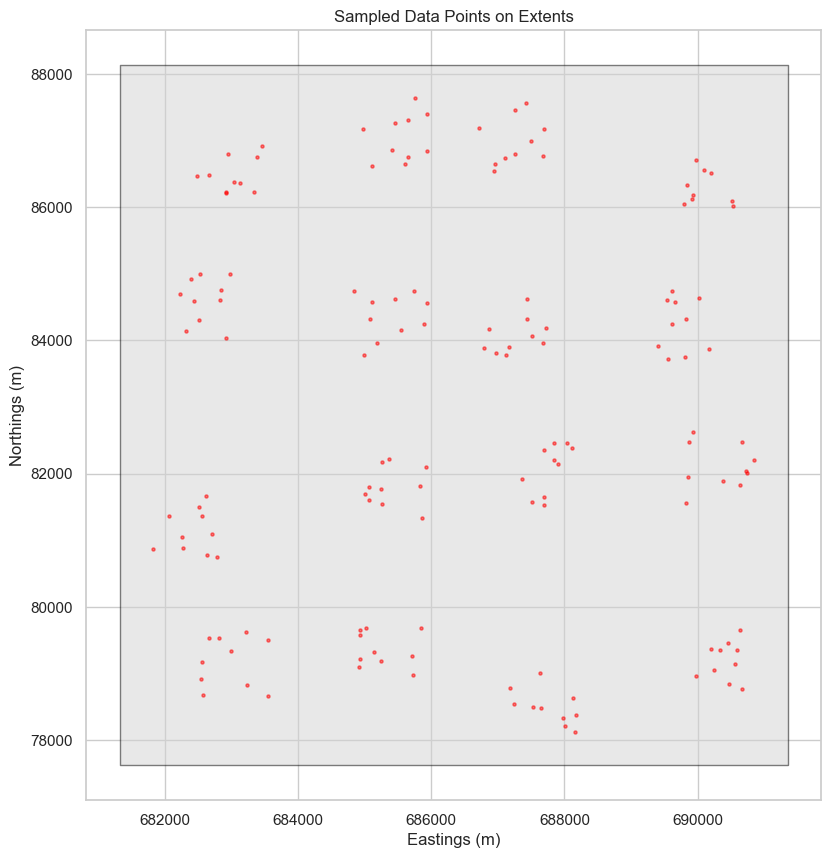

In [306]:
# Sampled Data
import pandas as pd
import geopandas as gpd

path_to_sampled_data = "./data/exports/sampled_data.csv"
path_to_extents = "./data/other_vectors/bbox.shp"

# Read the sampled data and extents
sampled_data = pd.read_csv(path_to_sampled_data, index_col=0)
extents = gpd.read_file(path_to_extents)


# Convert to GeoDataFrame and set the coordinate reference system (CRS)
sampled_data = gpd.GeoDataFrame(sampled_data, geometry=gpd.points_from_xy(sampled_data['lon'], sampled_data['lat']), crs=extents.crs)
sampled_data.drop(columns=['lon', 'lat'], inplace=True)
# Plot the sampled data points on top of the extents
ax = extents.plot(color='lightgrey', edgecolor='black', alpha=0.5, figsize=(10, 10))
sampled_data.plot(ax=ax, color='red', markersize=5, alpha=0.5)
ax.set_title("Sampled Data Points on Extents")
ax.set_xlabel("Eastings (m)")
ax.set_ylabel("Northings (m)")

## Data Cleaning


In [307]:
import pandas as pd

# Drop duplicates
sampled_data = sampled_data.drop_duplicates()

# Treat 'dynamic_world' as a categorical variable
sampled_data['dynamic_world'] = sampled_data['dynamic_world'].astype(int)

# If you want to One-Hot Encode it (recommended for ML models)
# sampled_data = pd.get_dummies(sampled_data, columns=['dynamic_world'], prefix='dw')

# Optionally cap outliers (only for continuous variables)
def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply outlier capping to numerical columns
# But now we skip newly created one-hot columns
numerical_cols = sampled_data.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = [col for col in numerical_cols if not col.startswith('dw_')]

for col in numerical_cols:
    sampled_data[col] = cap_outliers(sampled_data[col])

print("Data cleaned and categorical handled successfully!")


Data cleaned and categorical handled successfully!


## Data Tranfromation and Feature Engineering 


In [308]:
from sklearn.preprocessing import StandardScaler

# Scale only continuous numeric features
scaler = StandardScaler()

# Select numeric columns (excluding one-hot encoded columns like 'dw_1')
numeric_cols = [col for col in sampled_data.columns if sampled_data[col].dtype in ['float64', 'int64'] and col not in ['dynamic_world']]

# Fit and transform
sampled_data[numeric_cols] = scaler.fit_transform(sampled_data[numeric_cols])


## Feature Selection and Dimensionality Reduction

In [309]:
bands_s2 = ['s2_B2', 's2_B3', 's2_B4', 's2_B5', 's2_B6', 's2_B7', 's2_B8', 's2_B8A', 's2_B9', 's2_B11', 's2_B12']
bands_s1 = ['s1_VV', 's1_VH']
indices = ['s2_BSI', 's2_NDVI','s2_NBR', 's2_NDSI', 's2_SAVI', 's1_RVI', 's1_NDI','s1_CPR', 's1_VVVHR']

all_bands = bands_s2 + bands_s1 + indices

In [310]:
# RFE to select only 5 bands from s2 (sentinel-2) and s1 (sentinel-1)
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

y = sampled_data['predSOC']
X = sampled_data.drop(columns=['predSOC', 'geometry', 'dynamic_world'])  # Drop the target variable and geometry

# select all columns that start with 's2_' and 's1_'
X = X.loc[:, X.columns.str.startswith(('s2_B', 's1_V'))]

# model = GradientBoostingRegressor(n_estimators=100, random_state=42)  # Use a regression model for RFE
model = XGBRegressor(n_estimators=100, random_state=42)  # Use a regression model for RFE
rfe = RFE(model, n_features_to_select=5)  # Select top 5 features
rfe = rfe.fit(X, y)
# Get the selected features
selected_features = X.columns[rfe.support_]

In [311]:
bands_s2_selected = [col for col in selected_features if col.startswith('s2_')]

selected_bands = bands_s2_selected + indices
bands_s2_rejected = [col for col in all_bands if col not in selected_bands]

# Drop the unselected bands from the sampled data
sampled_data.drop(columns=bands_s2_rejected, inplace=True)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Target and Features
y = sampled_data['predSOC']

# Features: remove target + geometry
X = sampled_data.drop(columns=['predSOC', 'dynamic_world', 'geometry'])
X = X.select_dtypes(include=['int64', 'float64'])  # Keep only numeric

# Use RandomForestRegressor (NOT classifier!)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Recursive Feature Elimination
rfe = RFE(estimator=model, n_features_to_select=20)
rfe.fit(X, y)

# Selected Features
selected_features_rfe = X.columns[rfe.support_].tolist()

print("Top 15 features selected by RFE:\n", selected_features_rfe)

Top 15 features selected by RFE:
 ['s2_B5', 's2_B8', 's2_B11', 's2_B12', 's2_BSI', 's2_NDVI', 's2_NBR', 's2_NDSI', 's2_SAVI', 's1_RVI', 's1_NDI', 'aspect', 'slope', 'curvature', 'twi', 'elevation', 'rivers_distance', 'modis_et', 'modis_lst', 'chirps_precipitation']


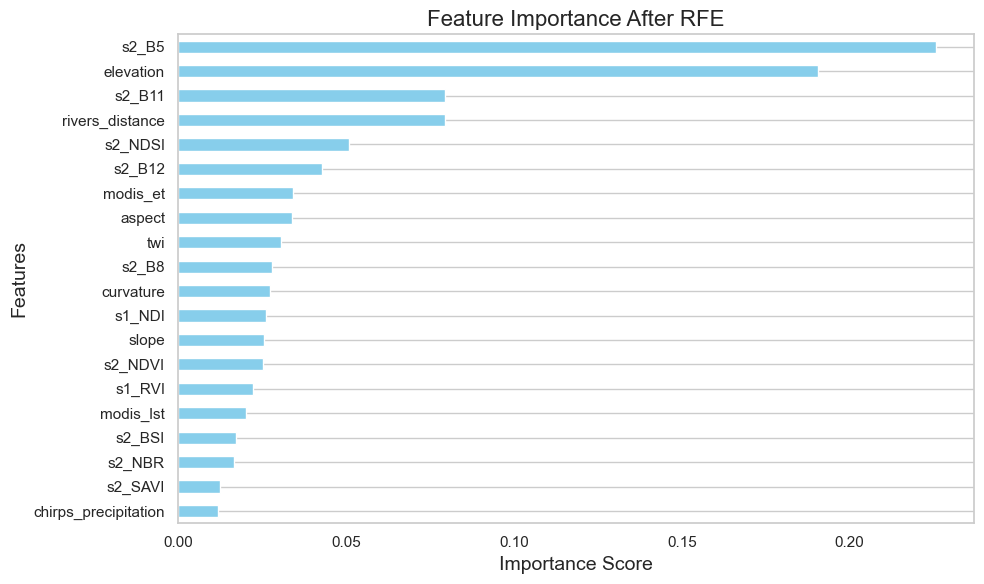

In [313]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Retrain the model with selected features
model.fit(X[selected_features_rfe], y)

# Step 2: Get feature importances
importances = model.feature_importances_

# Step 3: Create a DataFrame for plotting
feat_importances = pd.Series(importances, index=selected_features_rfe)
feat_importances = feat_importances.sort_values(ascending=False)

# Step 4: Plot
plt.figure(figsize=(10,6))
feat_importances.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()  # Highest importance at top
plt.title('Feature Importance After RFE', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.grid(axis='x')
plt.tight_layout()
plt.show()


,s2_B5,s2_B8,s2_B11,s2_B12,s2_BSI,s2_NDVI,s2_NBR,s2_NDSI,s2_SAVI,s1_RVI,...,aspect,slope,curvature,twi,elevation,rivers_distance,modis_et,modis_lst,chirps_precipitation,predSOC
PointID,,,,,,,,,,,,,,,,,,,,,
1GYL,0.370727,0.402354,0.382111,-0.112015,-0.060906,0.402850,0.242020,0.729414,0.421727,-1.285472,...,-0.570282,-0.778419,-0.373576,-0.043580,-0.670489,0.626032,0.755191,-0.504148,1.395817,-0.863099
X3L4,1.710523,0.572219,1.156244,1.099618,0.332866,-0.095888,-0.429478,0.166539,0.068341,-1.296296,...,-1.390583,-0.477800,-0.030232,-0.697750,-0.633721,0.482011,0.755191,-0.504148,1.395817,-0.053567
LQ8E,0.341601,1.030115,0.313758,0.338554,-0.459300,0.563039,0.216201,0.514697,0.730508,1.076393,...,-1.551471,-0.433645,-0.030232,1.032276,-0.744024,0.062823,0.157362,-0.144688,1.395817,-1.005892
ZTB7,0.201797,0.559295,0.227920,-0.326015,-0.246191,0.522286,0.461417,0.726820,0.560754,-1.590000,...,-0.874779,-0.898284,-0.030232,0.320833,-0.964630,-0.726802,-0.358945,-0.144688,1.395817,1.320526
9HYQ,0.141603,1.124279,0.549813,-0.305004,-0.476454,0.904066,0.681644,1.413624,1.029714,-0.969847,...,-1.246974,-0.259145,0.313113,-0.797751,-1.001397,-0.840199,-0.358945,-0.144688,1.395817,0.732664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L8QB,-0.508877,-1.983137,-0.225115,0.500416,1.382673,-1.359519,-1.477429,-0.853306,-1.523957,0.513578,...,1.164127,1.505458,0.313113,-0.822755,0.469307,2.495881,-0.535577,-2.506854,-1.387066,2.070704
0WR2,-0.405966,0.919334,-0.205245,-0.679310,-0.731033,0.771160,0.872279,0.609502,0.862978,-0.644798,...,0.747367,2.755381,0.656457,-1.254020,0.248702,2.299192,1.543239,-2.506854,-1.387066,0.514144
ZPKW,0.706647,1.295067,0.421851,0.105099,-0.503895,0.518823,0.472297,0.301767,0.768644,-0.215562,...,1.318078,-0.619320,-0.716921,0.638275,0.506075,2.005588,0.510625,-1.575192,-1.387066,-0.845151


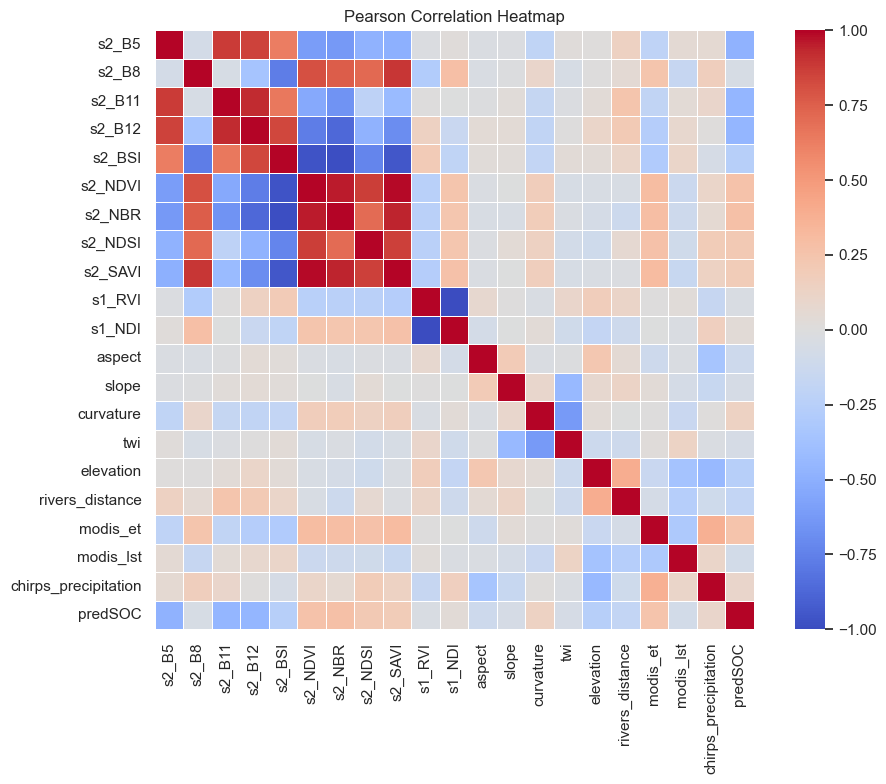

In [342]:
import seaborn as sns
df = sampled_data[selected_features_rfe+['predSOC']]
# Calculate Pearson correlation
corr = df.corr(method='pearson')

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with a color map of your choice
sns.heatmap(
    corr, 
    # annot=True,              # Show correlation values
    cmap='coolwarm',         # Color scheme
    vmin=-1, vmax=1,         # Color scale range
    linewidths=0.5,          # Width of cell borders
    square=True,             # Square cells
    fmt='.2f'                # Format annotation to 2 decimal places
)

plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

# Machine Learning

## Train Test Splitting

In [314]:
from sklearn.model_selection import train_test_split
# X and y with selected features
X_selected = X[selected_features_rfe]
y_selected = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42
)

## Grid Search and Hyperparameter Tuning

In [315]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import pandas as pd

# Define models and their param grids
models = {
    'RandomForest': (RandomForestRegressor(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }),
    
    'XGBoost': (XGBRegressor(random_state=42, objective='reg:squarederror'), {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    }),
    
    'SVR': (Pipeline([
        ('scaler', StandardScaler()), 
        ('svr', SVR())
    ]), {
        'svr__C': [0.1, 1, 10],
        'svr__epsilon': [0.01, 0.1],
        'svr__kernel': ['rbf', 'linear']
    })
}

# Create a list to hold results
results = []

# Loop through models
for name, (model, params) in models.items():
    print(f"\nTraining and tuning {name}...")
    
    grid = GridSearchCV(model, params, 
                        cv=5, 
                        scoring='neg_root_mean_squared_error', 
                        n_jobs=-1, 
                        verbose=1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Evaluate
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'RMSE': rmse,
        'R2_Score': r2,
        'MAE': mae
    })

# Create a DataFrame to view all results
results_df = pd.DataFrame(results)
print("\n📊 All Model Results:")
print(results_df.sort_values(by="RMSE"))



Training and tuning RandomForest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training and tuning XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Training and tuning SVR...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

📊 All Model Results:
          Model                                        Best Params      RMSE  \
0  RandomForest  {'max_depth': 20, 'min_samples_split': 2, 'n_e...  0.739056   
2           SVR  {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__kerne...  0.804227   
1       XGBoost  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...  0.826519   

   R2_Score       MAE  
0  0.518250  0.601405  
2  0.429541  0.639122  
1  0.397478  0.690032  


In [343]:
results_df.to_csv("./data/exports/model_results.csv", index=False)

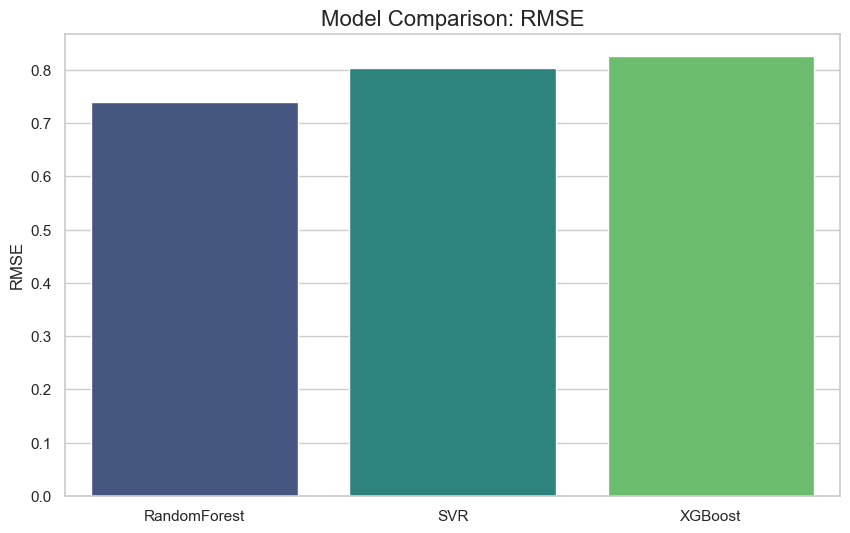

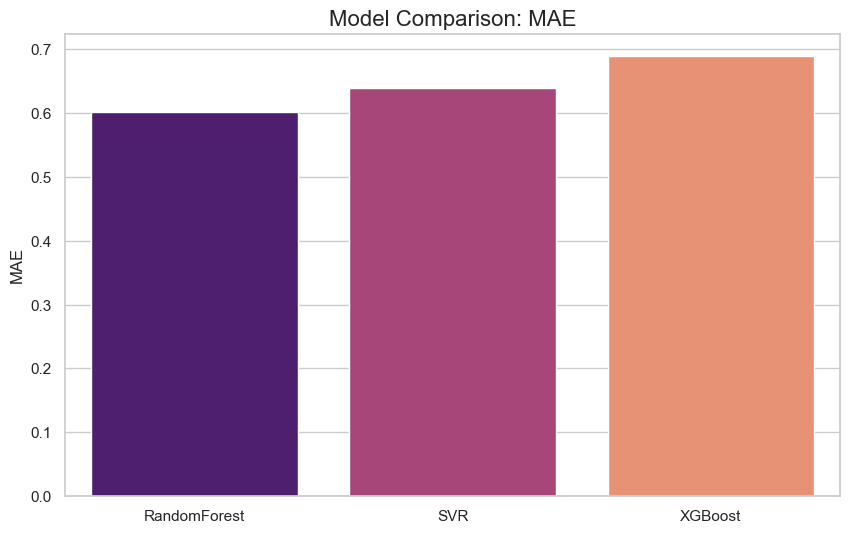

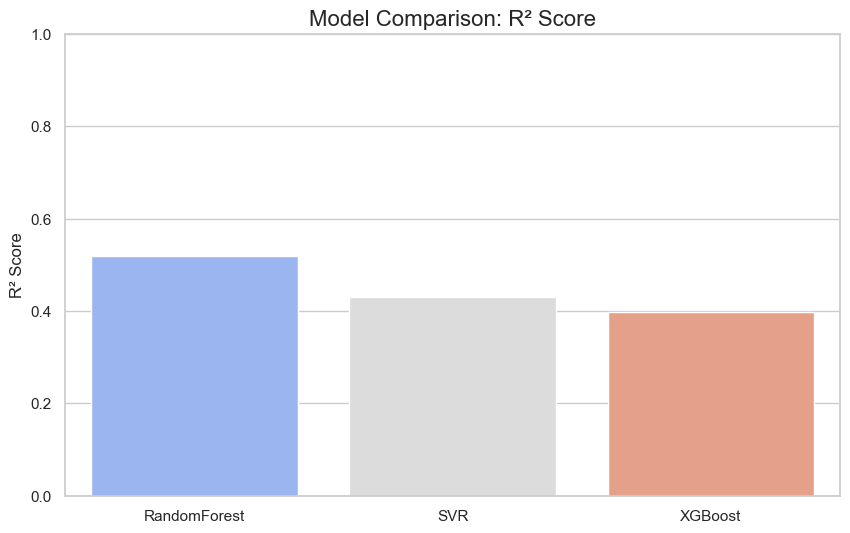

In [335]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Plot RMSE and MAE

# RMSE Plot

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='RMSE', data=results_df.sort_values('RMSE'), palette="viridis")
plt.title('Model Comparison: RMSE', fontsize=16)
plt.ylabel('RMSE')
plt.xlabel('')

# MAE Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='MAE', data=results_df.sort_values('MAE'), palette="magma")
plt.title('Model Comparison: MAE', fontsize=16)
plt.ylabel('MAE')
plt.xlabel('')

# plt.tight_layout()
plt.show()

# Plot R2 Score separately
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2_Score', data=results_df.sort_values('R2_Score', ascending=False), palette="coolwarm")
plt.title('Model Comparison: R² Score', fontsize=16)
plt.ylabel('R² Score')
plt.xlabel('')
plt.ylim(0, 1)  # Because R² is between 0 and 1
plt.show()


## Random Forest Fitting

In [317]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Define your features (X) and target (y)
X = sampled_data[selected_features_rfe]  # Adjust as needed
y = sampled_data['predSOC']

# 2. Split the dataset (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees
    max_depth=None,    # Let trees grow until pure
    random_state=42,
    n_jobs=-1          # Use all CPU cores
)
rf_model.fit(X_train, y_train)

# 4. Predict on the test set
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest MAE: {mae:.4f}")
print(f"Random Forest R2 Score: {r2:.4f}")


Random Forest RMSE: 0.7209
Random Forest MAE: 0.5884
Random Forest R2 Score: 0.5416


In [318]:
import joblib

# Save the best model
joblib.dump(rf_model, 'best_random_forest_model.pkl')

# Later, to load it:
# loaded_model = joblib.load('best_random_forest_model.pkl')


['best_random_forest_model.pkl']

## Raster SOC Prediction

In [319]:
from soc_scripts.extraction import sample_rasters_at_points
# Sample the rasters at the points
sentinel_rasters= {
    's2_B2': './data/exports/s2/sentinel2.B2.tif',
    's2_B3': './data/exports/s2/sentinel2.B3.tif',
    's2_B4': './data/exports/s2/sentinel2.B4.tif',
    's2_B5': './data/exports/s2/sentinel2.B5.tif',
    's2_B6': './data/exports/s2/sentinel2.B6.tif',
    's2_B7': './data/exports/s2/sentinel2.B7.tif',
    's2_B8': './data/exports/s2/sentinel2.B8.tif',
    's2_B8A': './data/exports/s2/sentinel2.B8A.tif',
    's2_B9': './data/exports/s2/sentinel2.B9.tif',
    's2_B11': './data/exports/s2/sentinel2.B11.tif',
    's2_B12': './data/exports/s2/sentinel2.B12.tif',
    's2_BSI': './data/exports/s2/sentinel2.BSI.tif',
    's2_NDVI': './data/exports/s2/sentinel2.NDVI.tif',
    's2_NBR': './data/exports/s2/sentinel2.NBR.tif',
    's2_NDSI': './data/exports/s2/sentinel2.NDSI.tif',
    's2_SAVI': './data/exports/s2/sentinel2.SAVI.tif',
    's1_VV': './data/exports/s1/sentinel1.VV.tif',
    's1_VH': './data/exports/s1/sentinel1.VH.tif',
    's1_RVI': './data/exports/s1/sentinel1.RVI.tif',
    's1_NDI': './data/exports/s1/sentinel1.NDI.tif',
    's1_CPR': './data/exports/s1/sentinel1.CPR.tif',
    's1_VVVHR': './data/exports/s1/sentinel1.VVVHR.tif',
}
other_gee = {
    'modis_et': './data/exports/modis_et.tif',
    'modis_lst': './data/exports/modis_lst.tif',
    'dynamic_world': './data/exports/dynamic_world_lulc.tif',
    'chirps_precipitation': './data/exports/chirps_precipitation.tif',
    'ph_0_20': './data/exports/ph_0_20.tif',
}
constants_dict = {
    'aspect': './data/rasters/aspect_sichei.tif',
    'slope': './data/rasters/slope_sichei.tif',
    'curvature': './data/rasters/curvature_sichei.tif',
    'twi': './data/rasters/model_twi.tif',
    'elevation': './data/rasters/srtm_30.tif',
    'rivers_distance': './data/rasters/rivers_distance_sichei.tif',
    # 'roads_distance': './data/rasters/roads_distances_sichei.tif',
}
# Combine all rasters into a single dictionary
all_rasters = {**sentinel_rasters, **constants_dict, **other_gee}
# select from all rasters only the ones that are in the sampled data
all_rasters = {k: v for k, v in all_rasters.items() if k in selected_features_rfe}

### Prepare raster layers for prediction

In [320]:
from rasterio.warp import Resampling
import os

In [321]:
from soc_scripts.extraction import sample_rasters_at_points
# Sample the rasters at the points
sentinel_rasters= {
    's2_B2': './data/exports/s2/sentinel2.B2.tif',
    's2_B3': './data/exports/s2/sentinel2.B3.tif',
    's2_B4': './data/exports/s2/sentinel2.B4.tif',
    's2_B5': './data/exports/s2/sentinel2.B5.tif',
    's2_B6': './data/exports/s2/sentinel2.B6.tif',
    's2_B7': './data/exports/s2/sentinel2.B7.tif',
    's2_B8': './data/exports/s2/sentinel2.B8.tif',
    's2_B8A': './data/exports/s2/sentinel2.B8A.tif',
    's2_B9': './data/exports/s2/sentinel2.B9.tif',
    's2_B11': './data/exports/s2/sentinel2.B11.tif',
    's2_B12': './data/exports/s2/sentinel2.B12.tif',
    's2_BSI': './data/exports/s2/sentinel2.BSI.tif',
    's2_NDVI': './data/exports/s2/sentinel2.NDVI.tif',
    's2_NBR': './data/exports/s2/sentinel2.NBR.tif',
    's2_NDSI': './data/exports/s2/sentinel2.NDSI.tif',
    's2_SAVI': './data/exports/s2/sentinel2.SAVI.tif',
    's1_VV': './data/exports/s1/sentinel1.VV.tif',
    's1_VH': './data/exports/s1/sentinel1.VH.tif',
    's1_RVI': './data/exports/s1/sentinel1.RVI.tif',
    's1_NDI': './data/exports/s1/sentinel1.NDI.tif',
    's1_CPR': './data/exports/s1/sentinel1.CPR.tif',
    's1_VVVHR': './data/exports/s1/sentinel1.VVVHR.tif',
}
other_gee = {
    'modis_et': './data/exports/modis_et.tif',
    'modis_lst': './data/exports/modis_lst.tif',
    'dynamic_world': './data/exports/dynamic_world_lulc.tif',
    'chirps_precipitation': './data/exports/chirps_precipitation.tif',
    'ph_0_20': './data/exports/ph_0_20.tif',
}
constants_dict = {
    'aspect': './data/rasters/aspect_sichei.tif',
    'slope': './data/rasters/slope_sichei.tif',
    'curvature': './data/rasters/curvature_sichei.tif',
    'twi': './data/rasters/model_twi.tif',
    'elevation': './data/rasters/srtm_30.tif',
    'rivers_distance': './data/rasters/rivers_distance_sichei.tif',
    # 'roads_distance': './data/rasters/roads_distances_sichei.tif',
}
# Combine all rasters into a single dictionary
all_rasters = {**sentinel_rasters, **constants_dict, **other_gee}
# select from all rasters only the ones that are in the sampled data
all_rasters = {k: v for k, v in all_rasters.items() if k in selected_features_rfe}
all_rasters

{'s2_B5': './data/exports/s2/sentinel2.B5.tif',
 's2_B8': './data/exports/s2/sentinel2.B8.tif',
 's2_B11': './data/exports/s2/sentinel2.B11.tif',
 's2_B12': './data/exports/s2/sentinel2.B12.tif',
 's2_BSI': './data/exports/s2/sentinel2.BSI.tif',
 's2_NDVI': './data/exports/s2/sentinel2.NDVI.tif',
 's2_NBR': './data/exports/s2/sentinel2.NBR.tif',
 's2_NDSI': './data/exports/s2/sentinel2.NDSI.tif',
 's2_SAVI': './data/exports/s2/sentinel2.SAVI.tif',
 's1_RVI': './data/exports/s1/sentinel1.RVI.tif',
 's1_NDI': './data/exports/s1/sentinel1.NDI.tif',
 'aspect': './data/rasters/aspect_sichei.tif',
 'slope': './data/rasters/slope_sichei.tif',
 'curvature': './data/rasters/curvature_sichei.tif',
 'twi': './data/rasters/model_twi.tif',
 'elevation': './data/rasters/srtm_30.tif',
 'rivers_distance': './data/rasters/rivers_distance_sichei.tif',
 'modis_et': './data/exports/modis_et.tif',
 'modis_lst': './data/exports/modis_lst.tif',
 'chirps_precipitation': './data/exports/chirps_precipitation.ti

In [322]:
from soc_scripts.raster_fn import clip_raster_with_geodataframe, align_raster

def process_raster_collection(raster_dict, aoi_gdf, output_dir):
    """
    Process a collection of rasters using SRTM as reference:
    1. First clip the SRTM raster using the AOI GeoDataFrame
    2. Then align all other rasters to match the clipped SRTM
    
    Parameters:
    -----------
    raster_dict : dict
        Dictionary with raster names as keys and file paths as values
    aoi_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing the AOI geometry(s)
    output_dir : str
        Directory to save the processed rasters
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Verify SRTM is in the dictionary
    if 'elevation' not in raster_dict:
        raise ValueError("SRTM raster not found in the raster dictionary")
    
    # First, clip the SRTM raster
    srtm_path = raster_dict['elevation']
    clipped_srtm_path = os.path.join(output_dir, "elevation-clipped.tif")
    
    print(f"Clipping SRTM raster...")
    clipped_srtm = clip_raster_with_geodataframe(srtm_path, aoi_gdf, clipped_srtm_path)
    
    # Use the clipped SRTM as reference for all other rasters
    processed_rasters = {'elevation': clipped_srtm}
    
    # Process all other rasters
    for name, path in raster_dict.items():
        if name != 'elevation':
            print(f"Processing {name} raster...")
            
            # Choose resampling method based on raster type
            if name.lower() in ['landcover', 'landuse', 'classification']:
                # Use nearest neighbor for categorical data
                resampling_method = Resampling.nearest
            else:
                # Use bilinear for continuous data
                resampling_method = Resampling.bilinear
            
            # Define output path
            output_path = os.path.join(output_dir, f"{name}-aligned.tif")
            
            # Align raster to clipped SRTM
            aligned_raster = align_raster(path, clipped_srtm, output_path, resampling_method)
            processed_rasters[name] = aligned_raster
    
    return processed_rasters

In [323]:
all_rasters =  all_rasters
aoi_gdf = extents.copy()
output_dir = "./data/clipped_rs/"
processed_rasters = process_raster_collection(all_rasters, aoi_gdf, output_dir)

print("\nProcessing completed. Summary:")
for name, path in processed_rasters.items():
    print(f"{name}: {path}")

Clipping SRTM raster...
Raster masked and saved to ./data/clipped_rs/elevation-clipped.tif
Processing s2_B5 raster...
Raster aligned and saved to ./data/clipped_rs/s2_B5-aligned.tif
Processing s2_B8 raster...
Raster aligned and saved to ./data/clipped_rs/s2_B8-aligned.tif
Processing s2_B11 raster...
Raster aligned and saved to ./data/clipped_rs/s2_B11-aligned.tif
Processing s2_B12 raster...
Raster aligned and saved to ./data/clipped_rs/s2_B12-aligned.tif
Processing s2_BSI raster...
Raster aligned and saved to ./data/clipped_rs/s2_BSI-aligned.tif
Processing s2_NDVI raster...
Raster aligned and saved to ./data/clipped_rs/s2_NDVI-aligned.tif
Processing s2_NBR raster...
Raster aligned and saved to ./data/clipped_rs/s2_NBR-aligned.tif
Processing s2_NDSI raster...
Raster aligned and saved to ./data/clipped_rs/s2_NDSI-aligned.tif
Processing s2_SAVI raster...
Raster aligned and saved to ./data/clipped_rs/s2_SAVI-aligned.tif
Processing s1_RVI raster...
Raster aligned and saved to ./data/clipped

### Load Feature Rasters

In [324]:
import os
# Load all the rasters in a directory to a dict the name (first part of the name of the file, delimiter=_), path
def load_rasters_to_dict(directory, delimiter='-'):
    """
    Load all rasters in a directory into a dictionary.
    
    Parameters:
    -----------
    directory : str
        Path to the directory containing raster files
    delimiter : str, optional
        Delimiter used to split the filename for the key (default is '_')
        
    Returns:
    --------
    dict
        Dictionary with raster names as keys and file paths as values
    """
    raster_dict = {}
    
    # Iterate through all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.tif'):
            # Split the filename using the delimiter and take the first part as the key
            key = filename.split(delimiter)[0]
            raster_dict[key] = os.path.join(directory, filename)
    
    return raster_dict
# Example usage
loaded_rasters = load_rasters_to_dict('./data/clipped_rs/')

In [325]:
def reorder_dict(data_dict, reference_order):
  """
  Reorders a dictionary based on the keys in a reference list.

  Args:
    data_dict (dict): The dictionary to be reordered.
    reference_order (list): A list of keys specifying the desired order.

  Returns:
    dict: A new dictionary with the keys ordered according to the reference.
          Keys in the data_dict that are not in the reference_order will
          be added at the end (though this example assumes all keys are present).
  """
  ordered_dict = {}
  for key in reference_order:
    if key in data_dict:
      ordered_dict[key] = data_dict[key]
  # Add any remaining keys from data_dict that were not in reference_order
  for key, value in data_dict.items():
    if key not in ordered_dict:
      ordered_dict[key] = value
  return ordered_dict

# Get the keys from the reference dictionary to use as the order
reference_order_list = list(all_rasters.keys())

# Reorder the dictionary using the function
loaded_rasters = reorder_dict(loaded_rasters, reference_order_list)

## Random Forest Prediction

In [ ]:
import rasterio
import numpy as np

# Load and stack rasters
raster_arrays = []
first = True

for feature_name, path in loaded_rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)  # Read first band
        raster_arrays.append(arr)
        
        # Save metadata from first raster
        if first:
            meta = src.meta
            first = False

# Stack into 3D array
raster_stack = np.stack(raster_arrays, axis=0)

# Reshape into (num_pixels, num_features)
n_layers, height, width = raster_stack.shape
X_raster = raster_stack.reshape(n_layers, height * width).T

# Predict using trained model
raster_predictions = rf_model.predict(X_raster)

# Reshape back to 2D raster
predicted_raster = raster_predictions.reshape(height, width)

# Save the prediction
out_meta = meta.copy()
out_meta.update({"count": 1, "dtype": "float32"})

with rasterio.open('predicted_SOC_map.tif', 'w', **out_meta) as dest:
    dest.write(predicted_raster.astype(np.float32), 1)

print("✅ Prediction map saved as 'predicted_SOC_map.tif'")


# Results

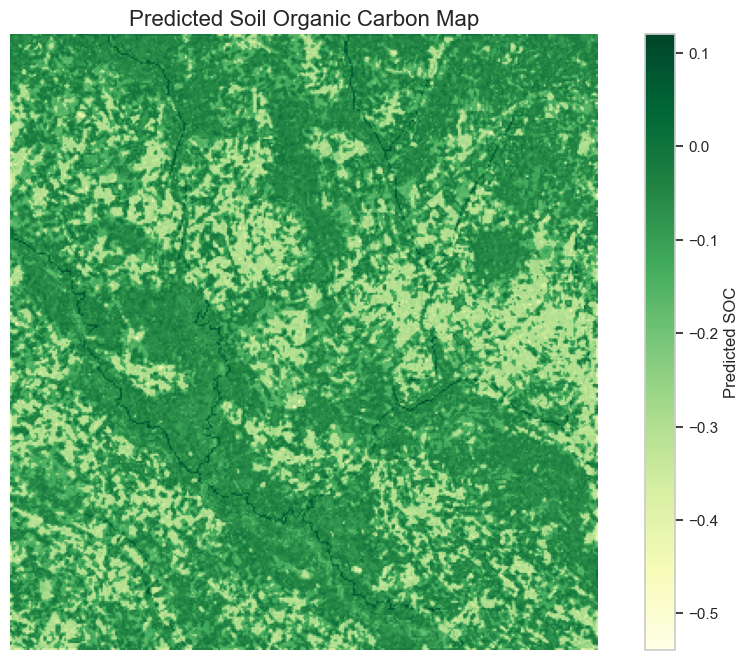

In [328]:
import matplotlib.pyplot as plt

# Load predicted raster
with rasterio.open('predicted_SOC_map.tif') as src:
    predicted_raster = src.read(1)
    predicted_raster[predicted_raster == src.nodata] = np.nan  # Handle nodata nicely

# Plot
plt.figure(figsize=(12, 8))
cmap = plt.cm.YlGn  # Yellow-Green color palette (good for vegetation/soil)
plt.imshow(predicted_raster, cmap=cmap)
plt.colorbar(label='Predicted SOC')
plt.title('Predicted Soil Organic Carbon Map', fontsize=16)
plt.axis('off')
plt.show()

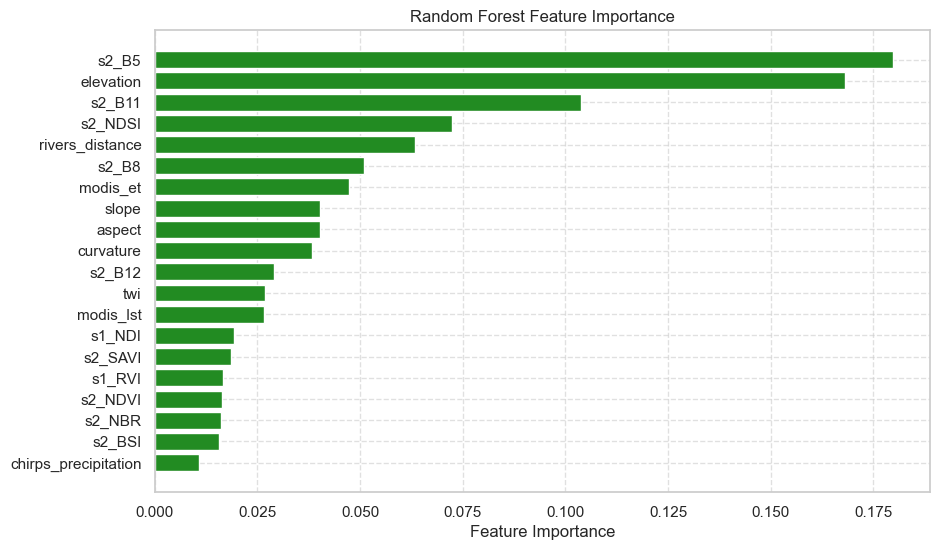

In [329]:
import pandas as pd

# Feature importances
importances = rf_model.feature_importances_
feature_names = list(loaded_rasters.keys())

# Create a dataframe
feat_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importances['Feature'], feat_importances['Importance'], color='forestgreen')
plt.gca().invert_yaxis()  # Most important on top
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


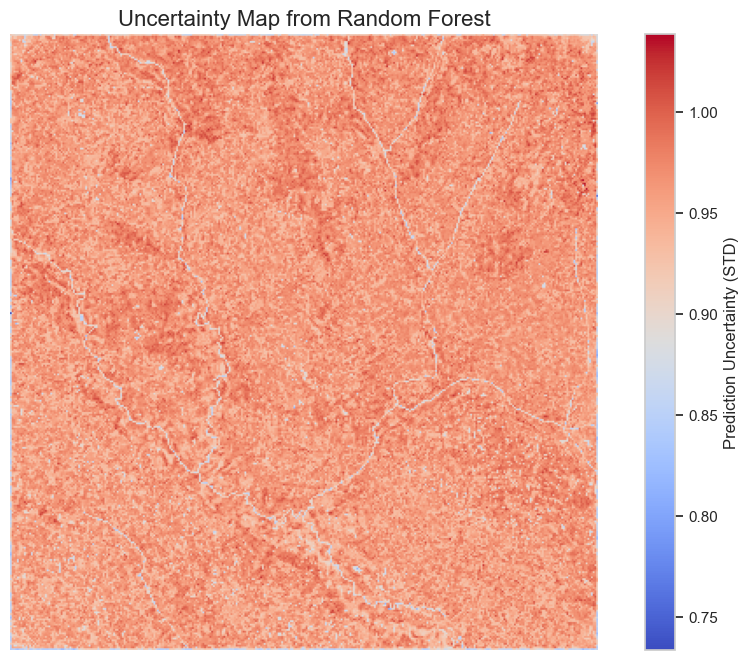

In [331]:
# Collect predictions from each tree
all_tree_preds = np.stack([tree.predict(X_raster) for tree in rf_model.estimators_], axis=0)

# Compute std dev across trees -> uncertainty
uncertainty = np.std(all_tree_preds, axis=0)

# Reshape
uncertainty_raster = uncertainty.reshape(height, width)

# Save uncertainty raster
uncertainty_meta = meta.copy()
uncertainty_meta.update({"count": 1, "dtype": "float32"})

with rasterio.open('uncertainty_map.tif', 'w', **uncertainty_meta) as dest:
    dest.write(uncertainty_raster.astype(np.float32), 1)

# Visualize
plt.figure(figsize=(12, 8))
plt.imshow(uncertainty_raster, cmap='coolwarm')
plt.colorbar(label='Prediction Uncertainty (STD)')
plt.title('Uncertainty Map from Random Forest', fontsize=16)
plt.axis('off')
plt.show()
